In [ ]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torchaudio
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,roc_auc_score
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt

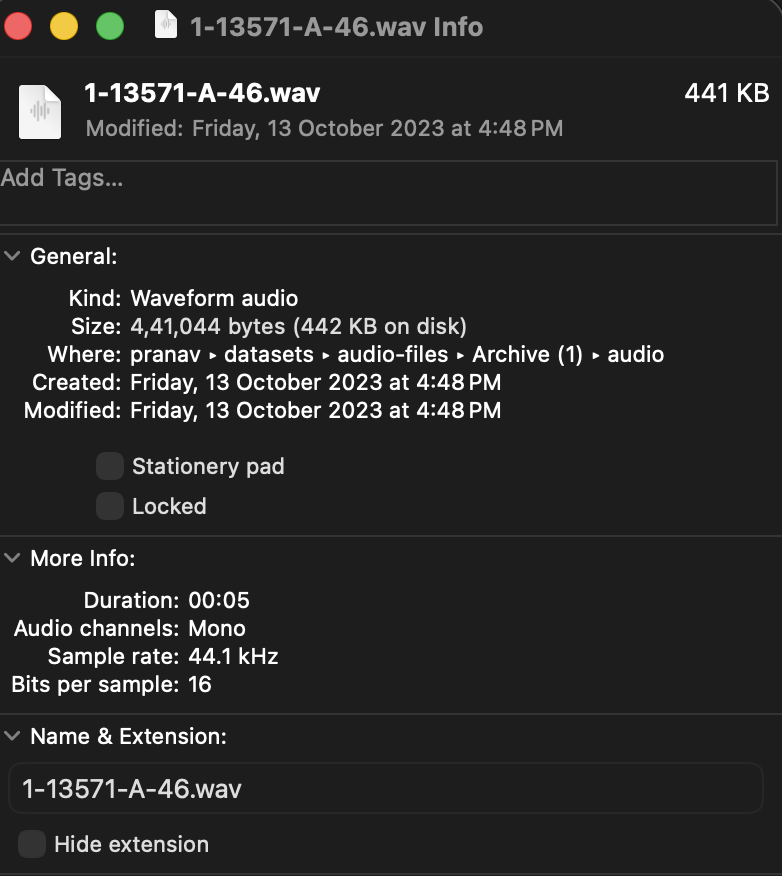

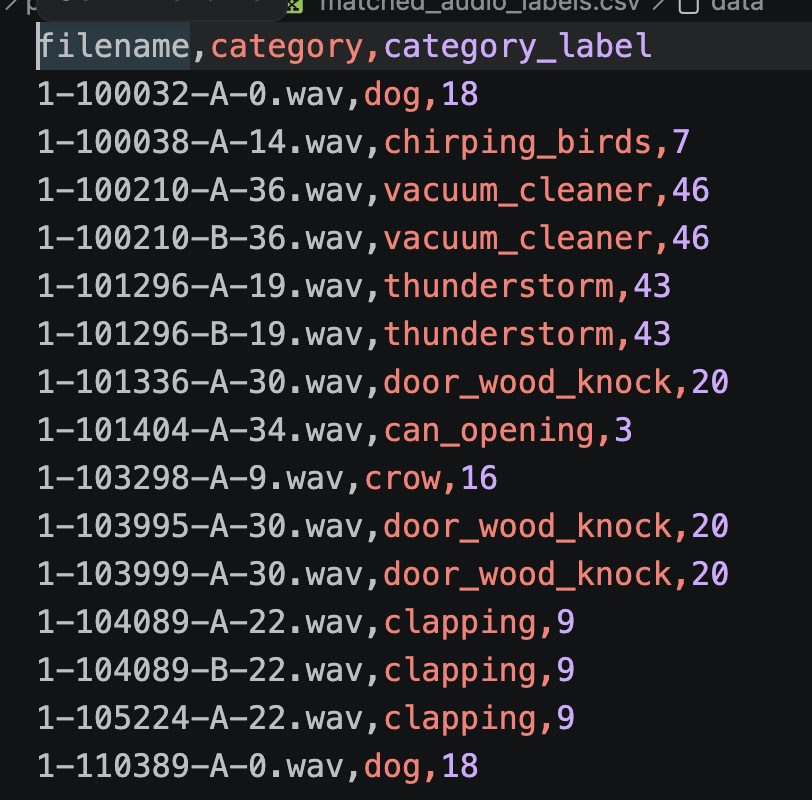

* Each audio is of 5 seconds
* Each audio is the .wav file
* sample rate is 44.1khz = 44100hz
* above is the CSV file of each audio
* different category audio file is there
* By looking the audio. Model need to predict the which category audio is it
* This means it is the multi class classification problem

In [ ]:
class AudioDataset(Dataset):

    def __init__(self, dataframe, audio_folder, target_sr=44100, duration=5):
        self.df = dataframe.reset_index(drop=True)
        self.audio_folder = audio_folder
        self.target_sr = target_sr
        self.fixed_length = target_sr * duration   # 44100 * 5 = 220500

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        file_name = self.df.loc[idx, 'filename']
        label = self.df.loc[idx, 'category_label']

        file_path = os.path.join(self.audio_folder, file_name)

        # waveform is a tensor that return [channels, samples]
        # so this is mono audio not stereo audio
        # so channels = 1 so [1,220500]
        # sr is 44100
        waveform, sr = torchaudio.load(file_path)
        # shape: (channels, samples)


        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Resample
        if sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(sr, self.target_sr)
            waveform = resampler(waveform)

        # Normalize to [-1,1]
        waveform = waveform / waveform.abs().max()

        # Pad or trim
        length = waveform.shape[1]

        if length < self.fixed_length:
            pad_amount = self.fixed_length - length
            waveform = F.pad(waveform, (0, pad_amount))

        else:
            waveform = waveform[:, :self.fixed_length]

        # for entire batch [B,1,220500]
        return waveform.float(), torch.tensor(label).long()

CNN MODEL
* 1st cnn we have the 1d kernel input channel is 1 and output is 16 channels
* ((n-k+2p)/s) + 1 => ((220500 - 9 + 2(4))/2) + 1 = [B,16,110250]
* max pooling [B,16,27562]
* 2nd cnn input 16 channels and output 32
* [B,16,110250] -> [B,32,13781]
* 3rd cnn input 32 channels and output 64 channels
* [B,32,13781] -> [B,64,1723]
* 4th cnn input channels 64 output 128 channels
* [B,64,1723] -> [B,128,862]
* Adaptive avg pooling apply the average [B,128,1]
* flatten [B,128]
* [B,128] -> [B,64] first linear
* [B,64] -> [B, 50] to final classes

In [ ]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes=50,using_cnn=True):
        super().__init__()
        self.using_cnn = using_cnn

        self.features = nn.Sequential(

            nn.Conv1d(1, 16, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(16, 32, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        if self.using_cnn:
            x = self.classifier(x)
        return x

In [ ]:
def show_confusion_matrix(y_true, y_pred, title, figsize=(8,6)):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [ ]:
def plot_loss_curve(losses):

    plt.figure(figsize=(8,5))
    plt.plot(losses, marker='o')
    plt.title("Training Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

100%|██████████| 50/50 [00:22<00:00,  2.21it/s]


Fold 1 | Epoch 1 | Loss 3.7579


100%|██████████| 50/50 [00:22<00:00,  2.18it/s]


Fold 1 | Epoch 2 | Loss 3.4146


100%|██████████| 50/50 [00:22<00:00,  2.22it/s]


...

Fold 1 | Epoch 149 | Loss 0.9778


100%|██████████| 50/50 [00:23<00:00,  2.17it/s]


Fold 1 | Epoch 150 | Loss 0.9839


100%|██████████| 13/13 [00:05<00:00,  2.21it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Validation Results
Loss     : 1.9798
Accuracy : 0.5125
F1 Score : 0.4815
ROC AUC  : 0.9582

Classification Report:

              precision    recall  f1-score   support

           0       0.25      0.12      0.17         8
           1       0.50      0.38      0.43         8
           2       0.67      0.25      0.36         8
           3       0.36      1.00      0.53         8
           4       0.33      0.62      0.43         8
           5       0.50      0.75      0.60         8
           6       0.50      0.38      0.43         8
           7       0.43      0.75      0.55         8
           8       0.56      0.62      0.59         8
           9       0.50      0.12      0.20         8
          10       0.75      0.75      0.75         8
          11       0.29      0.50      0.36         8
          12       0.71      0.62      0.67         8
          13       0.80      1.00      0.89         8
          14       0.40      0.25      0.31         8
          15      

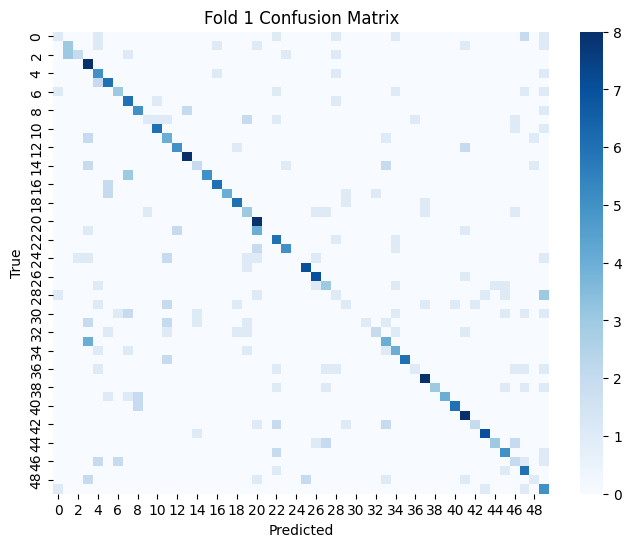

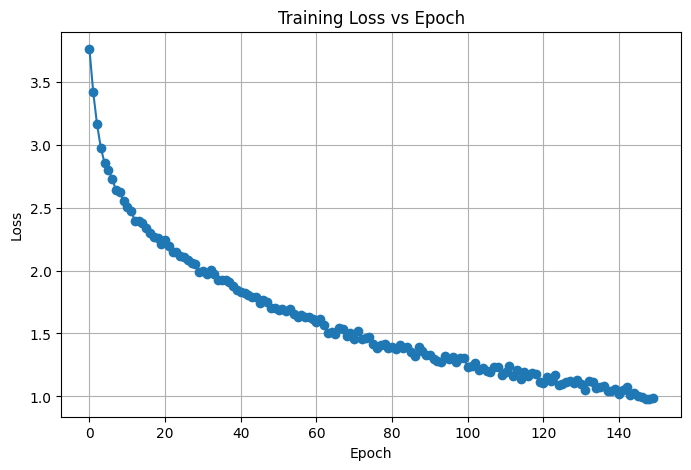

100%|██████████| 50/50 [00:22<00:00,  2.17it/s]


Fold 2 | Epoch 1 | Loss 3.7758


100%|██████████| 50/50 [00:22<00:00,  2.20it/s]


Fold 2 | Epoch 2 | Loss 3.4233


100%|██████████| 50/50 [00:22<00:00,  2.22it/s]


...

Fold 2 | Epoch 149 | Loss 0.9342


100%|██████████| 50/50 [00:22<00:00,  2.18it/s]


Fold 2 | Epoch 150 | Loss 0.9301


100%|██████████| 13/13 [00:05<00:00,  2.40it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Validation Results
Loss     : 2.2083
Accuracy : 0.4900
F1 Score : 0.4810
ROC AUC  : 0.9509

Classification Report:

              precision    recall  f1-score   support

           0       0.35      0.75      0.48         8
           1       0.33      0.12      0.18         8
           2       0.75      0.75      0.75         8
           3       1.00      0.12      0.22         8
           4       0.33      0.25      0.29         8
           5       0.67      0.50      0.57         8
           6       0.29      0.25      0.27         8
           7       0.62      0.62      0.62         8
           8       0.43      0.38      0.40         8
           9       0.62      0.62      0.62         8
          10       0.88      0.88      0.88         8
          11       0.00      0.00      0.00         8
          12       0.33      0.12      0.18         8
          13       0.44      1.00      0.62         8
          14       0.50      0.38      0.43         8
          15      

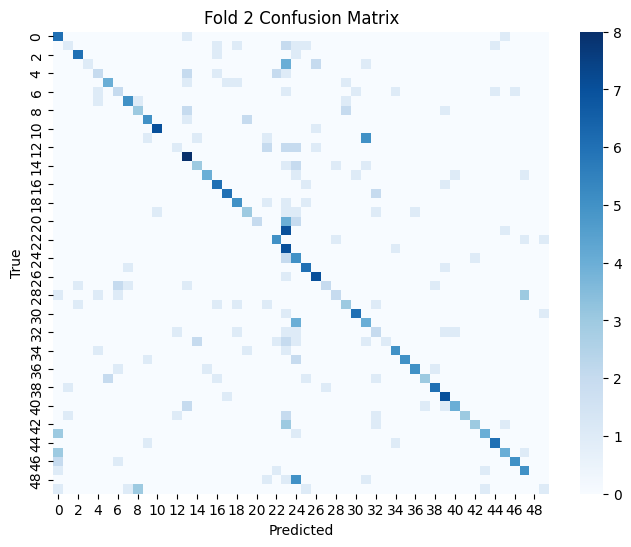

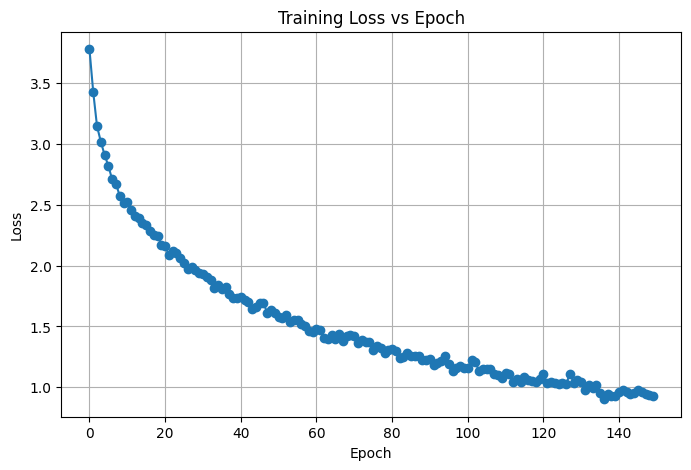

100%|██████████| 50/50 [00:22<00:00,  2.24it/s]


Fold 3 | Epoch 1 | Loss 3.7757


100%|██████████| 50/50 [00:22<00:00,  2.22it/s]


Fold 3 | Epoch 2 | Loss 3.4157


100%|██████████| 50/50 [00:22<00:00,  2.21it/s]


...

Fold 3 | Epoch 149 | Loss 1.0646


100%|██████████| 50/50 [00:22<00:00,  2.21it/s]


Fold 3 | Epoch 150 | Loss 1.0236


100%|██████████| 13/13 [00:05<00:00,  2.20it/s]



Validation Results
Loss     : 1.7227
Accuracy : 0.5550
F1 Score : 0.5473
ROC AUC  : 0.9664

Classification Report:

              precision    recall  f1-score   support

           0       0.43      0.38      0.40         8
           1       0.38      0.62      0.48         8
           2       1.00      0.88      0.93         8
           3       1.00      0.62      0.77         8
           4       0.56      0.62      0.59         8
           5       0.38      0.38      0.38         8
           6       0.40      0.50      0.44         8
           7       0.78      0.88      0.82         8
           8       0.50      0.25      0.33         8
           9       0.86      0.75      0.80         8
          10       0.83      0.62      0.71         8
          11       0.50      0.25      0.33         8
          12       0.25      0.12      0.17         8
          13       0.54      0.88      0.67         8
          14       0.50      0.12      0.20         8
          15      

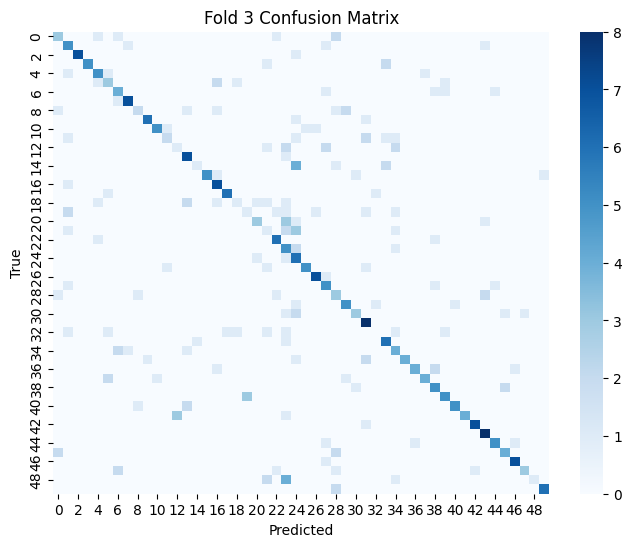

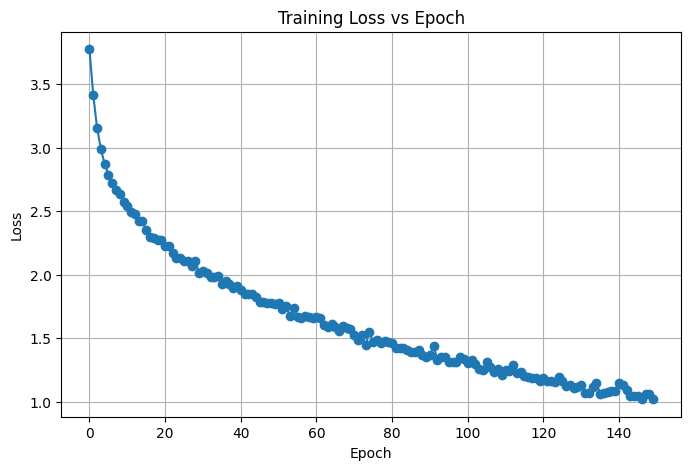

100%|██████████| 50/50 [00:22<00:00,  2.21it/s]


Fold 4 | Epoch 1 | Loss 3.7710


100%|██████████| 50/50 [00:22<00:00,  2.23it/s]


Fold 4 | Epoch 2 | Loss 3.4610


100%|██████████| 50/50 [00:22<00:00,  2.19it/s]


...

Fold 4 | Epoch 149 | Loss 1.0640


100%|██████████| 50/50 [00:22<00:00,  2.23it/s]


Fold 4 | Epoch 150 | Loss 1.0451


100%|██████████| 13/13 [00:05<00:00,  2.41it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Validation Results
Loss     : 2.3427
Accuracy : 0.4275
F1 Score : 0.4181
ROC AUC  : 0.9483

Classification Report:

              precision    recall  f1-score   support

           0       0.17      0.50      0.26         8
           1       0.20      0.12      0.15         8
           2       0.33      0.25      0.29         8
           3       1.00      0.25      0.40         8
           4       0.27      0.38      0.32         8
           5       1.00      0.50      0.67         8
           6       0.50      0.38      0.43         8
           7       0.50      0.38      0.43         8
           8       0.47      0.88      0.61         8
           9       0.67      1.00      0.80         8
          10       0.86      0.75      0.80         8
          11       0.00      0.00      0.00         8
          12       0.20      0.25      0.22         8
          13       0.50      0.50      0.50         8
          14       0.00      0.00      0.00         8
          15      

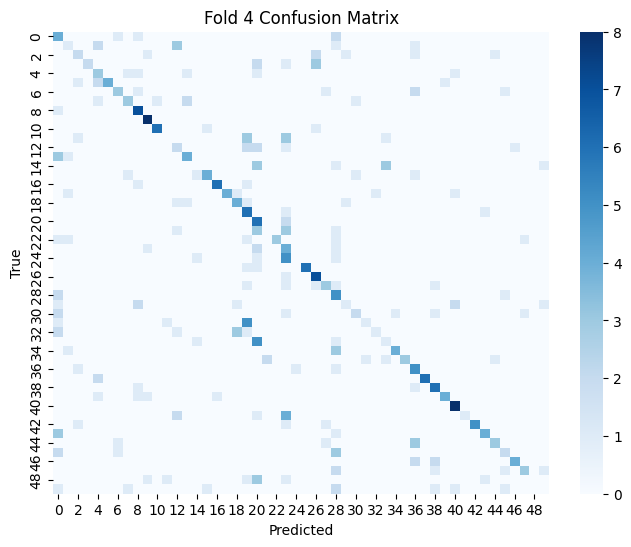

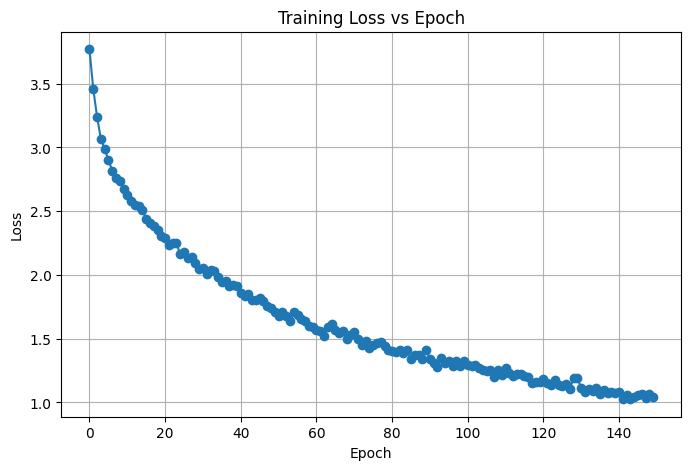

100%|██████████| 50/50 [00:23<00:00,  2.12it/s]


Fold 5 | Epoch 1 | Loss 3.7700


100%|██████████| 50/50 [00:23<00:00,  2.10it/s]


Fold 5 | Epoch 2 | Loss 3.4113


100%|██████████| 50/50 [00:22<00:00,  2.24it/s]


...

Fold 5 | Epoch 149 | Loss 1.0028


100%|██████████| 50/50 [00:22<00:00,  2.18it/s]


Fold 5 | Epoch 150 | Loss 1.0350


100%|██████████| 13/13 [00:05<00:00,  2.29it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Validation Results
Loss     : 1.7530
Accuracy : 0.5525
F1 Score : 0.5374
ROC AUC  : 0.9648

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.67      0.25      0.36         8
           2       0.37      0.88      0.52         8
           3       0.80      0.50      0.62         8
           4       0.38      0.38      0.38         8
           5       1.00      0.50      0.67         8
           6       0.43      0.38      0.40         8
           7       0.67      0.50      0.57         8
           8       0.57      0.50      0.53         8
           9       0.64      0.88      0.74         8
          10       1.00      0.88      0.93         8
          11       1.00      0.38      0.55         8
          12       0.33      0.12      0.18         8
          13       0.67      0.25      0.36         8
          14       0.38      0.62      0.48         8
          15      

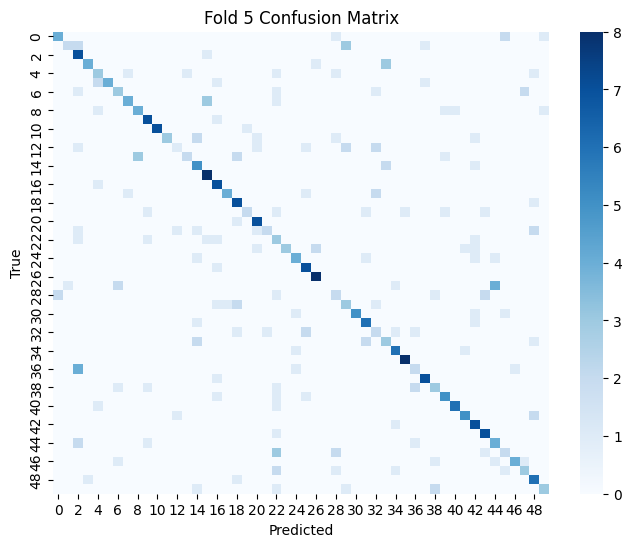

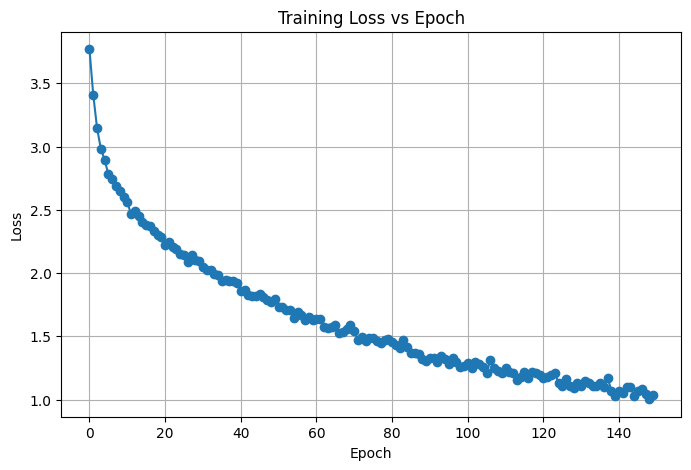

FINAL K-FOLD RESULTS
Fold 1: Acc=0.5125 | F1=0.4815 | AUC=0.9582
Fold 2: Acc=0.4900 | F1=0.4810 | AUC=0.9509
Fold 3: Acc=0.5550 | F1=0.5473 | AUC=0.9664
Fold 4: Acc=0.4275 | F1=0.4181 | AUC=0.9483
Fold 5: Acc=0.5525 | F1=0.5374 | AUC=0.9648

Average Results
Accuracy : 0.5075
F1 Score : 0.4931
ROC AUC  : 0.9577


In [ ]:
df = pd.read_csv('/kaggle/input/datasets/pranav6224/audio-csv/matched_audio_labels.csv')
audio_path = '/kaggle/input/datasets/pranav6224/audio-dataset/audio'
batch_size = 32
num_classes = 50
epochs = 150
device = 'cuda' if torch.cuda.is_available() else 'cpu'
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_acc = []
fold_f1 = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['category_label'])):

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    train_dataset = AudioDataset(train_df, audio_path)
    val_dataset   = AudioDataset(val_df, audio_path)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )


    audio_model = AudioCNN(num_classes).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        audio_model.parameters(),
        lr=1e-3
    )



    losses = []

    for epoch in range(epochs):

        audio_model.train()

        epoch_losses = []

        for batch, labels in tqdm(train_loader):

            batch = batch.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = audio_model(batch)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            epoch_losses.append(loss.item())

        avg_loss = np.mean(epoch_losses)
        losses.append(avg_loss)

        print(f"Fold {fold+1} | Epoch {epoch+1} | Loss {avg_loss:.4f}")


    audio_model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    val_losses = []

    with torch.no_grad():

        for batch, labels in tqdm(val_loader):

            batch = batch.to(device)
            labels = labels.to(device)

            outputs = audio_model(batch)

            loss = criterion(outputs, labels)
            val_losses.append(loss.item())

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())



    avg_val_loss = np.mean(val_losses)

    acc = accuracy_score(all_labels, all_preds)

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        multi_class='ovr',
        average='weighted'
    )

    print("\nValidation Results")
    print(f"Loss     : {avg_val_loss:.4f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    show_confusion_matrix(
        all_labels,
        all_preds,
        title=f'Fold {fold+1} Confusion Matrix'
    )

    plot_loss_curve(
        losses,

    )



    fold_acc.append(acc)
    fold_f1.append(f1)
    fold_auc.append(roc_auc)



print("="*70)
print("FINAL K-FOLD RESULTS")
print("="*70)

for i in range(len(fold_acc)):

    print(
        f"Fold {i+1}: "
        f"Acc={fold_acc[i]:.4f} | "
        f"F1={fold_f1[i]:.4f} | "
        f"AUC={fold_auc[i]:.4f}"
    )

print("\nAverage Results")

print(f"Accuracy : {np.mean(fold_acc):.4f}")
print(f"F1 Score : {np.mean(fold_f1):.4f}")
print(f"ROC AUC  : {np.mean(fold_auc):.4f}")

In [ ]:
class MultiHeadAttentionScratch(nn.Module):
    def __init__(self, num_heads, din, dout):
        super().__init__()
        assert dout % num_heads == 0, "dout must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = dout // num_heads

        # Learnable projections
        self.w_query = nn.Linear(din, dout, bias=True)
        self.w_key   = nn.Linear(din, dout, bias=True)
        self.w_value = nn.Linear(din, dout, bias=True)

        # Final projection
        self.out_proj = nn.Linear(dout, dout)

    def forward(self, x):

        # x shape = (B, num_tokens, din)
        # Example = (B, 863, 128)
        B, N, _ = x.shape

        q = self.w_query(x)   # (B, N, dout)
        k = self.w_key(x)     # (B, N, dout)
        v = self.w_value(x)   # (B, N, dout)

       #[B,num_heads,num_tokens,head_dim]
        q = q.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        # [B,num_heads,num_tokens,num_tokens]
        attn_scores = q @ k.transpose(-2, -1)

        # To make the variance = 1
        attn_weights = torch.softmax(
            attn_scores / (self.head_dim ** 0.5),
            dim=-1
        )

       #[B,num_heads,num_tokens,head_dim]
        context = attn_weights @ v

       #[B,num_tokens,num_heads,head_dim] -> [B,num_tokens,embedding_dim]
        context = context.transpose(1, 2).reshape(B, N, -1)

        #[B,num_tokens,embedding_dim]
        out = self.out_proj(context)

        return out

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, num_heads=4, dim=128, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadAttentionScratch( num_heads=num_heads,din=dim,dout=dim)
        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.GELU(),
            nn.Linear(4 * dim, dim)
        )

        # Shared dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out1 = x
        out1 = self.norm1(out1)
        out1 = self.attn(out1)
        out1 = self.dropout(out1)
        x = x + out1

        out2 = x
        out2 = self.norm2(out2)
        out2 = self.mlp(out2)
        out2 = self.dropout(out2)
        return x + out2

In [ ]:
class AudioTransformer(nn.Module):
    def __init__(
        self,
        cnn_backbone,
        num_classes=50,
        embed_dim=128,
        num_heads=4,
        depth=2,
        num_tokens=862,
        dropout=0.1
    ):
        super().__init__()

        # CNN feature extractor
        self.cnn = cnn_backbone

        # CLS token
        self.cls_token = nn.Parameter(
            torch.randn(1, 1, embed_dim)
        )

        # Positional embedding
        self.pos_embed = nn.Parameter(
            torch.randn(1, num_tokens + 1, embed_dim)
        )

        self.pos_drop = nn.Dropout(dropout)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(
                num_heads=num_heads,
                dim=embed_dim,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        # Final norm
        self.norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        """
        x = (B,1,220500)
        """

        # -------------------------
        # CNN Features
        # (B,128,862)
        # -------------------------
        x = self.cnn(x)

        # -------------------------
        # Convert to tokens
        # (B,862,128)
        # -------------------------
        x = x.transpose(1, 2)

        B, N, D = x.shape

        # -------------------------
        # CLS Token
        # (B,1,128)
        # -------------------------
        cls = self.cls_token.expand(B, -1, -1)

        # (B,863,128)
        x = torch.cat([cls, x], dim=1)

        # -------------------------
        # Add Position Embedding
        # -------------------------
        x = x + self.pos_embed[:, :N+1, :]
        x = self.pos_drop(x)

        # -------------------------
        # Transformer Blocks
        # -------------------------
        for block in self.blocks:
            x = block(x)

        # -------------------------
        # Extract CLS token
        # (B,128)
        # -------------------------
        cls_out = x[:, 0, :]

        # -------------------------
        # Final Norm
        # -------------------------
        cls_out = self.norm(cls_out)

        # -------------------------
        # Classifier
        # -------------------------
        out = self.head(cls_out)

        return out

RUNNING AUDIO TRANSFORMER | HEADS = 1

Starting Fold 1


100%|██████████| 42/42 [00:20<00:00,  2.05it/s]


Heads 1 | Fold 1 | Epoch 1 | Loss 3.9285


100%|██████████| 42/42 [00:19<00:00,  2.19it/s]


Heads 1 | Fold 1 | Epoch 2 | Loss 3.8861


...

Heads 1 | Fold 1 | Epoch 99 | Loss 1.7985


100%|██████████| 42/42 [00:18<00:00,  2.23it/s]


Heads 1 | Fold 1 | Epoch 100 | Loss 1.7360


100%|██████████| 21/21 [00:08<00:00,  2.35it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Validation Results
Loss     : 2.1082
Accuracy : 0.4213
F1 Score : 0.3930
ROC AUC  : 0.9362

Classification Report:

              precision    recall  f1-score   support

           0       0.45      0.38      0.42        13
           1       0.20      0.14      0.17        14
           2       0.71      0.38      0.50        13
           3       0.61      0.85      0.71        13
           4       0.50      0.14      0.22        14
           5       0.40      0.15      0.22        13
           6       0.46      0.43      0.44        14
           7       0.67      0.62      0.64        13
           8       0.35      0.62      0.44        13
           9       0.18      0.15      0.17        13
          10       0.67      0.92      0.77        13
          11       0.00      0.00      0.00        14
          12       0.80      0.57      0.67        14
          13       0.50      0.69      0.58        13
          14       0.36      0.31      0.33        13
          15      

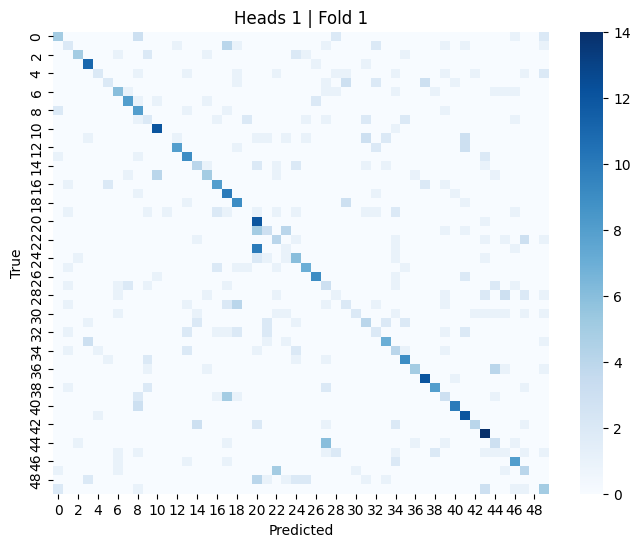

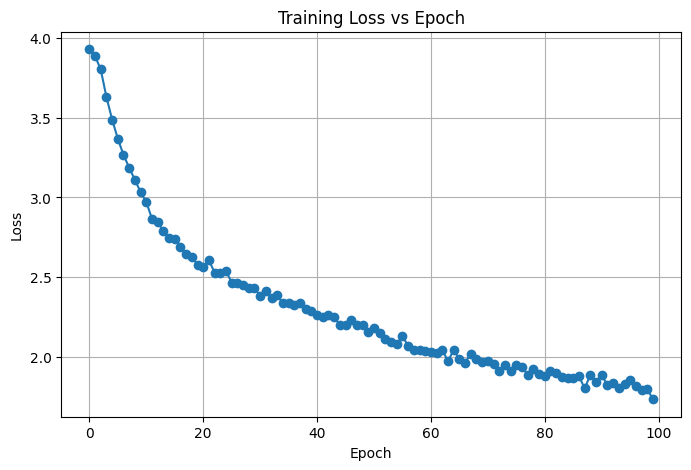


Starting Fold 2


100%|██████████| 42/42 [00:18<00:00,  2.24it/s]


Heads 1 | Fold 2 | Epoch 1 | Loss 3.9332


100%|██████████| 42/42 [00:18<00:00,  2.23it/s]


Heads 1 | Fold 2 | Epoch 2 | Loss 3.8997


...

Heads 1 | Fold 2 | Epoch 99 | Loss 1.7083


100%|██████████| 42/42 [00:18<00:00,  2.23it/s]


Heads 1 | Fold 2 | Epoch 100 | Loss 1.6821


100%|██████████| 21/21 [00:09<00:00,  2.32it/s]



Validation Results
Loss     : 1.9446
Accuracy : 0.4093
F1 Score : 0.3933
ROC AUC  : 0.9501

Classification Report:

              precision    recall  f1-score   support

           0       0.21      0.36      0.26        14
           1       0.45      0.38      0.42        13
           2       0.56      0.38      0.45        13
           3       0.32      0.54      0.40        13
           4       0.00      0.00      0.00        13
           5       0.06      0.08      0.07        13
           6       0.27      0.23      0.25        13
           7       0.60      0.43      0.50        14
           8       0.47      0.57      0.52        14
           9       0.44      0.50      0.47        14
          10       0.59      0.77      0.67        13
          11       0.50      0.15      0.24        13
          12       0.33      0.31      0.32        13
          13       0.70      0.50      0.58        14
          14       0.43      0.21      0.29        14
          15      

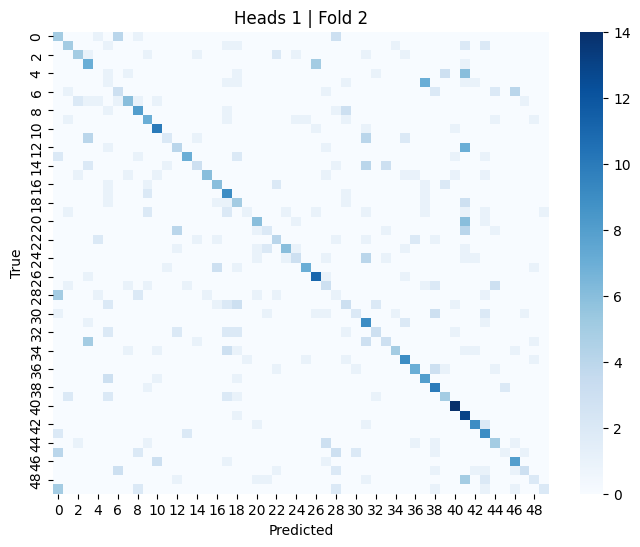

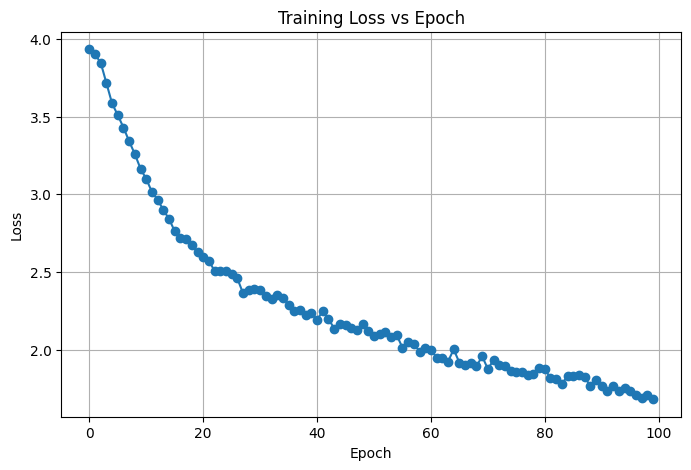


Starting Fold 3


100%|██████████| 42/42 [00:18<00:00,  2.21it/s]


Heads 1 | Fold 3 | Epoch 1 | Loss 3.9291


100%|██████████| 42/42 [00:18<00:00,  2.26it/s]


Heads 1 | Fold 3 | Epoch 2 | Loss 3.8891


...

Heads 1 | Fold 3 | Epoch 99 | Loss 1.7551


100%|██████████| 42/42 [00:19<00:00,  2.19it/s]


Heads 1 | Fold 3 | Epoch 100 | Loss 1.7693


100%|██████████| 21/21 [00:09<00:00,  2.26it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Validation Results
Loss     : 2.0667
Accuracy : 0.3904
F1 Score : 0.3647
ROC AUC  : 0.9447

Classification Report:

              precision    recall  f1-score   support

           0       0.23      0.23      0.23        13
           1       0.50      0.08      0.13        13
           2       0.50      0.64      0.56        14
           3       0.42      0.36      0.38        14
           4       0.23      0.23      0.23        13
           5       0.33      0.43      0.38        14
           6       0.22      0.31      0.26        13
           7       0.50      0.31      0.38        13
           8       0.31      0.31      0.31        13
           9       0.55      0.46      0.50        13
          10       0.82      0.64      0.72        14
          11       0.38      0.23      0.29        13
          12       0.00      0.00      0.00        13
          13       0.40      0.46      0.43        13
          14       0.23      0.38      0.29        13
          15      

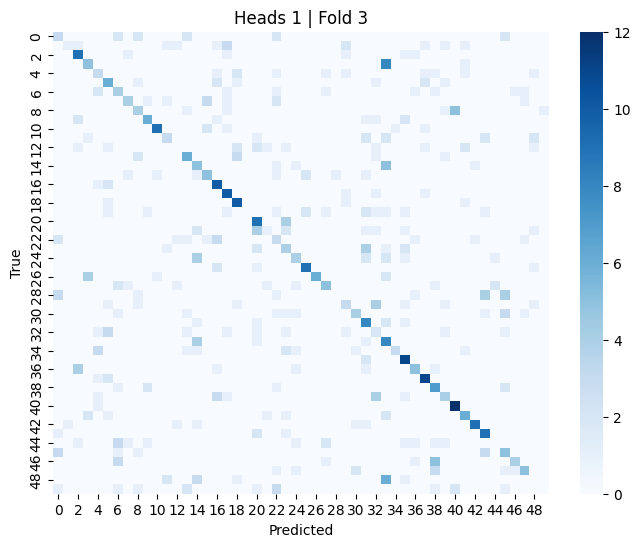

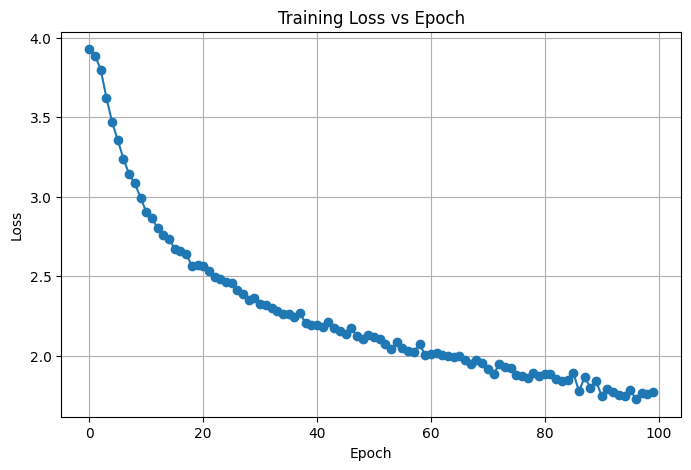

FINAL RESULTS | HEADS = 1
Fold 1: Acc=0.4213 | F1=0.3930 | AUC=0.9362
Fold 2: Acc=0.4093 | F1=0.3933 | AUC=0.9501
Fold 3: Acc=0.3904 | F1=0.3647 | AUC=0.9447

Average Results
Accuracy : 0.4070
F1 Score : 0.3837
ROC AUC  : 0.9437
RUNNING AUDIO TRANSFORMER | HEADS = 2

Starting Fold 1


100%|██████████| 42/42 [00:19<00:00,  2.17it/s]


Heads 2 | Fold 1 | Epoch 1 | Loss 3.9313


100%|██████████| 42/42 [00:19<00:00,  2.17it/s]


Heads 2 | Fold 1 | Epoch 2 | Loss 3.8980


...

Heads 2 | Fold 1 | Epoch 99 | Loss 1.6989


100%|██████████| 42/42 [00:18<00:00,  2.23it/s]


Heads 2 | Fold 1 | Epoch 100 | Loss 1.6921


100%|██████████| 21/21 [00:09<00:00,  2.32it/s]



Validation Results
Loss     : 2.0517
Accuracy : 0.4243
F1 Score : 0.3904
ROC AUC  : 0.9406

Classification Report:

              precision    recall  f1-score   support

           0       0.27      0.23      0.25        13
           1       0.50      0.29      0.36        14
           2       0.70      0.54      0.61        13
           3       0.25      0.69      0.37        13
           4       0.50      0.21      0.30        14
           5       0.43      0.23      0.30        13
           6       0.50      0.43      0.46        14
           7       0.50      0.54      0.52        13
           8       0.50      0.38      0.43        13
           9       0.50      0.23      0.32        13
          10       0.55      0.92      0.69        13
          11       0.00      0.00      0.00        14
          12       0.31      0.29      0.30        14
          13       0.64      0.54      0.58        13
          14       0.19      0.23      0.21        13
          15      

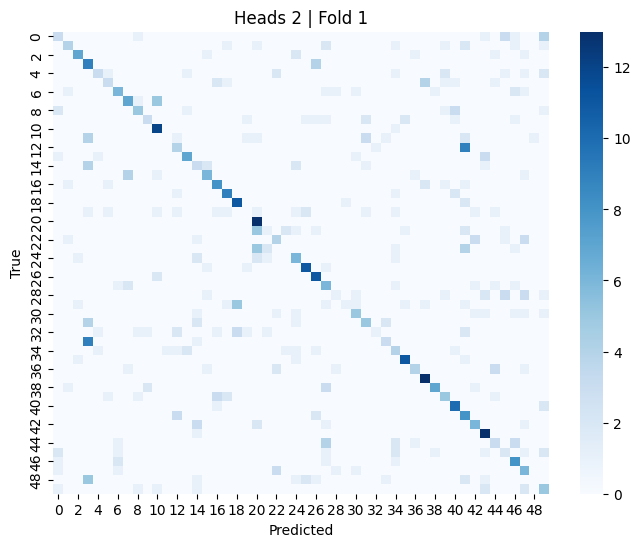

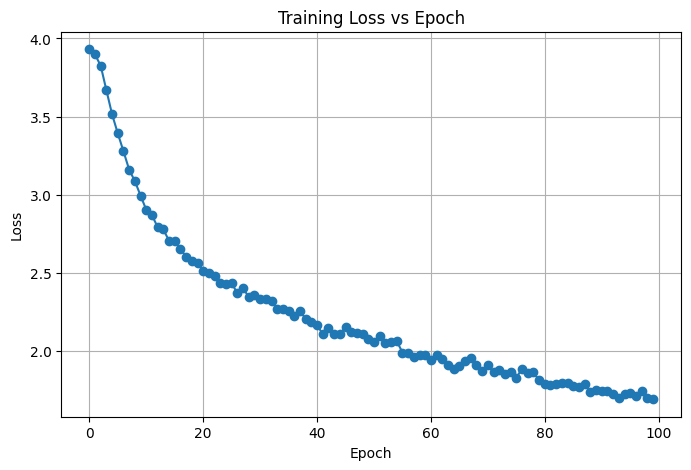


Starting Fold 2


100%|██████████| 42/42 [00:18<00:00,  2.21it/s]


Heads 2 | Fold 2 | Epoch 1 | Loss 3.9256


100%|██████████| 42/42 [00:18<00:00,  2.24it/s]


Heads 2 | Fold 2 | Epoch 2 | Loss 3.8916


...

Heads 2 | Fold 2 | Epoch 99 | Loss 1.7531


100%|██████████| 42/42 [00:19<00:00,  2.19it/s]


Heads 2 | Fold 2 | Epoch 100 | Loss 1.6788


100%|██████████| 21/21 [00:09<00:00,  2.20it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Validation Results
Loss     : 1.9592
Accuracy : 0.4213
F1 Score : 0.3985
ROC AUC  : 0.9505

Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.36      0.27        14
           1       0.43      0.23      0.30        13
           2       0.75      0.46      0.57        13
           3       0.67      0.46      0.55        13
           4       0.14      0.08      0.10        13
           5       0.31      0.38      0.34        13
           6       0.25      0.23      0.24        13
           7       0.67      0.57      0.62        14
           8       0.33      0.43      0.38        14
           9       0.36      0.29      0.32        14
          10       0.50      0.69      0.58        13
          11       0.00      0.00      0.00        13
          12       0.38      0.23      0.29        13
          13       0.50      0.64      0.56        14
          14       0.30      0.64      0.41        14
          15      

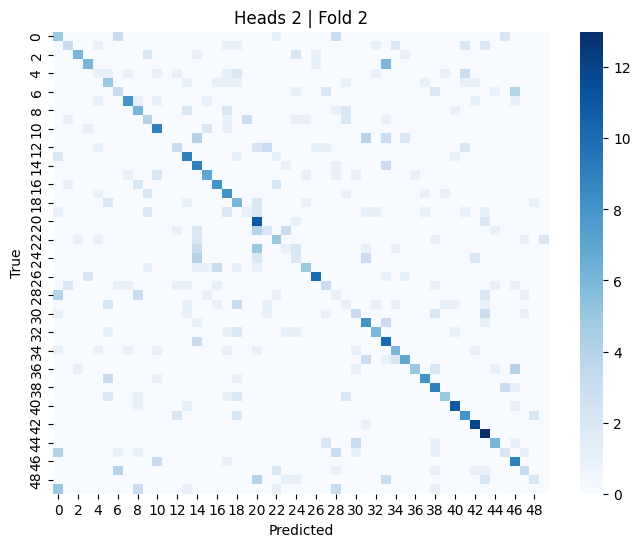

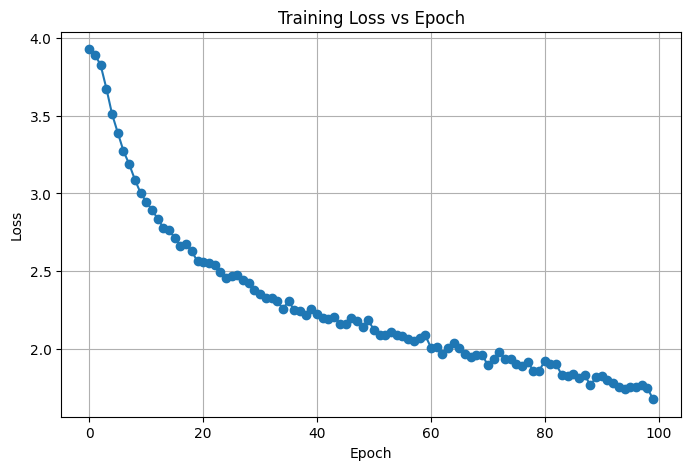


Starting Fold 3


100%|██████████| 42/42 [00:19<00:00,  2.13it/s]


Heads 2 | Fold 3 | Epoch 1 | Loss 3.9249


100%|██████████| 42/42 [00:19<00:00,  2.11it/s]


Heads 2 | Fold 3 | Epoch 2 | Loss 3.8981


...

Heads 2 | Fold 3 | Epoch 99 | Loss 1.8292


100%|██████████| 42/42 [00:19<00:00,  2.18it/s]


Heads 2 | Fold 3 | Epoch 100 | Loss 1.7721


100%|██████████| 21/21 [00:09<00:00,  2.26it/s]



Validation Results
Loss     : 2.0128
Accuracy : 0.3964
F1 Score : 0.3787
ROC AUC  : 0.9463

Classification Report:

              precision    recall  f1-score   support

           0       0.10      0.08      0.09        13
           1       0.44      0.31      0.36        13
           2       0.43      0.43      0.43        14
           3       0.46      0.86      0.60        14
           4       0.17      0.15      0.16        13
           5       0.33      0.43      0.38        14
           6       0.21      0.23      0.22        13
           7       0.50      0.31      0.38        13
           8       0.31      0.31      0.31        13
           9       0.42      0.38      0.40        13
          10       0.92      0.79      0.85        14
          11       0.18      0.15      0.17        13
          12       0.25      0.23      0.24        13
          13       0.44      0.31      0.36        13
          14       0.42      0.38      0.40        13
          15      

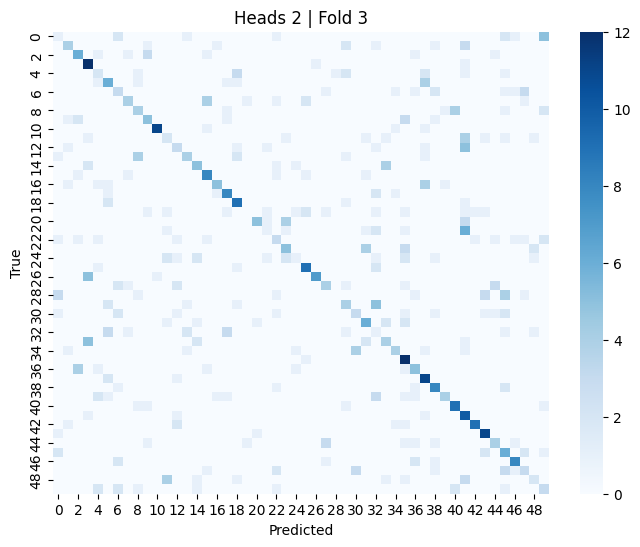

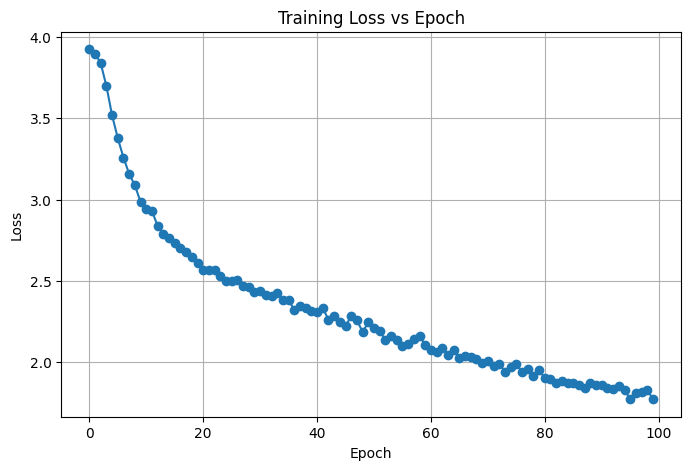

FINAL RESULTS | HEADS = 2
Fold 1: Acc=0.4243 | F1=0.3904 | AUC=0.9406
Fold 2: Acc=0.4213 | F1=0.3985 | AUC=0.9505
Fold 3: Acc=0.3964 | F1=0.3787 | AUC=0.9463

Average Results
Accuracy : 0.4140
F1 Score : 0.3892
ROC AUC  : 0.9458
RUNNING AUDIO TRANSFORMER | HEADS = 4

Starting Fold 1


100%|██████████| 42/42 [00:19<00:00,  2.13it/s]


Heads 4 | Fold 1 | Epoch 1 | Loss 3.9322


100%|██████████| 42/42 [00:19<00:00,  2.12it/s]


Heads 4 | Fold 1 | Epoch 2 | Loss 3.9103


...

Heads 4 | Fold 1 | Epoch 99 | Loss 1.7954


100%|██████████| 42/42 [00:19<00:00,  2.20it/s]


Heads 4 | Fold 1 | Epoch 100 | Loss 1.7894


100%|██████████| 21/21 [00:09<00:00,  2.28it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Validation Results
Loss     : 1.9803
Accuracy : 0.4558
F1 Score : 0.4410
ROC AUC  : 0.9410

Classification Report:

              precision    recall  f1-score   support

           0       0.44      0.31      0.36        13
           1       0.18      0.14      0.16        14
           2       0.56      0.38      0.45        13
           3       0.82      0.69      0.75        13
           4       0.40      0.14      0.21        14
           5       0.57      0.31      0.40        13
           6       0.45      0.36      0.40        14
           7       0.50      0.69      0.58        13
           8       0.44      0.54      0.48        13
           9       0.50      0.15      0.24        13
          10       1.00      0.77      0.87        13
          11       0.00      0.00      0.00        14
          12       0.33      0.14      0.20        14
          13       1.00      0.54      0.70        13
          14       0.29      0.31      0.30        13
          15      

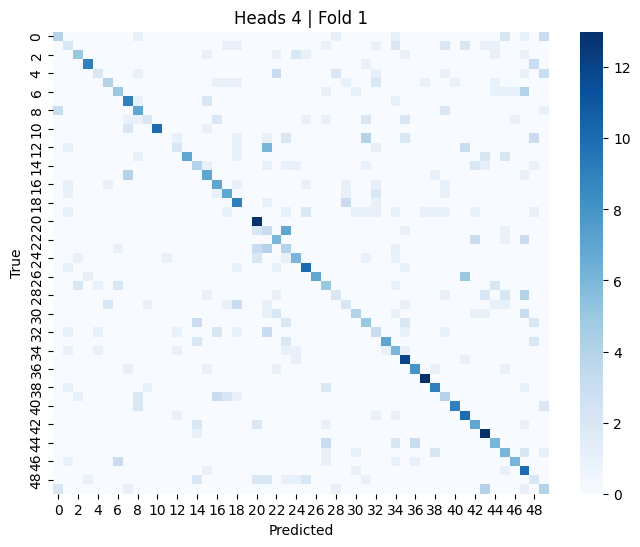

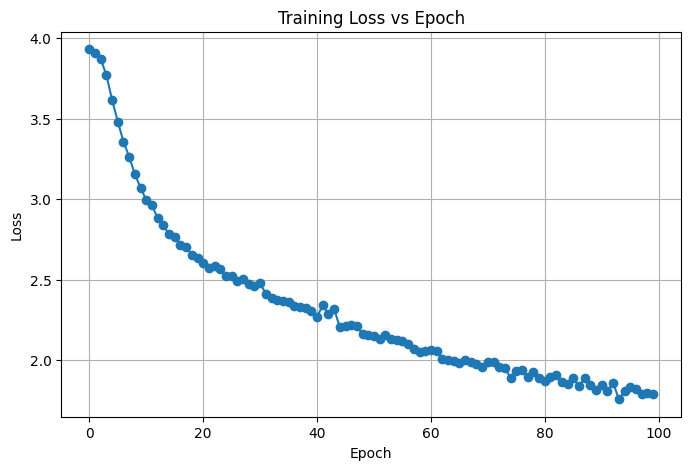


Starting Fold 2


100%|██████████| 42/42 [00:19<00:00,  2.19it/s]


Heads 4 | Fold 2 | Epoch 1 | Loss 3.9277


100%|██████████| 42/42 [00:19<00:00,  2.19it/s]


Heads 4 | Fold 2 | Epoch 2 | Loss 3.9023


...

100%|██████████| 42/42 [00:19<00:00,  2.18it/s]


Heads 4 | Fold 2 | Epoch 66 | Loss 1.8935


100%|██████████| 42/42 [00:19<00:00,  2.14it/s]


Heads 4 | Fold 2 | Epoch 67 | Loss 1.8936


 14%|█▍        | 6/42 [00:02<00:17,  2.11it/s]

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/pranav6224/audio-csv/matched_audio_labels.csv')
audio_path = '/kaggle/input/datasets/pranav6224/audio-dataset/audio'
batch_size = 32
num_classes = 50
epochs = 100
embed_dim = 128
num_transformer_blocks = 2
dropout = 0.1
num_tokens = 862 # after cnn i get this

device = 'cuda' if torch.cuda.is_available() else 'cpu'

skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

for heads in [1, 2, 4]:

    print("=" * 80)
    print(f"RUNNING AUDIO TRANSFORMER | HEADS = {heads}")
    print("=" * 80)

    fold_acc = []
    fold_f1 = []
    fold_auc = []


    for fold, (train_idx, val_idx) in enumerate(
        skf.split(df, df['category_label'])
    ):

        print(f"\nStarting Fold {fold+1}")

        # --------------------------------------------------
        # SPLIT DATA
        # --------------------------------------------------

        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df   = df.iloc[val_idx].reset_index(drop=True)

        train_dataset = AudioDataset(train_df, audio_path)
        val_dataset   = AudioDataset(val_df, audio_path)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False
        )

        # --------------------------------------------------
        # MODEL
        # --------------------------------------------------

        cnn_backbone = AudioCNN(num_classes = num_classes,using_cnn=False)

        audio_model = AudioTransformer(
            cnn_backbone=cnn_backbone,
            num_classes=num_classes,
            embed_dim=embed_dim,
            num_heads=heads,
            depth=num_transformer_blocks,
            num_tokens=num_tokens,
            dropout=dropout
        ).to(device)

        criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam(
            audio_model.parameters(),
            lr=1e-4
        )
        losses = []

        for epoch in range(epochs):
            audio_model.train()
            epoch_losses = []
            for batch, labels in tqdm(train_loader):
                batch = batch.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                outputs = audio_model(batch)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_losses.append(loss.item())
            avg_loss = np.mean(epoch_losses)
            losses.append(avg_loss)

            print(
                f"Heads {heads} | Fold {fold+1} | "
                f"Epoch {epoch+1} | Loss {avg_loss:.4f}"
            )

        # --------------------------------------------------
        # VALIDATION
        # --------------------------------------------------

        audio_model.eval()

        all_preds = []
        all_labels = []
        all_probs = []
        val_losses = []

        with torch.no_grad():

            for batch, labels in tqdm(val_loader):

                batch = batch.to(device)
                labels = labels.to(device)

                outputs = audio_model(batch)

                loss = criterion(outputs, labels)
                val_losses.append(loss.item())

                probs = torch.softmax(outputs, dim=1)

                preds = torch.argmax(probs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        # --------------------------------------------------
        # METRICS
        # --------------------------------------------------

        avg_val_loss = np.mean(val_losses)

        acc = accuracy_score(all_labels, all_preds)

        f1 = f1_score(
            all_labels,
            all_preds,
            average='weighted'
        )

        roc_auc = roc_auc_score(
            all_labels,
            all_probs,
            multi_class='ovr',
            average='weighted'
        )

        print("\nValidation Results")
        print(f"Loss     : {avg_val_loss:.4f}")
        print(f"Accuracy : {acc:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print(f"ROC AUC  : {roc_auc:.4f}")

        print("\nClassification Report:\n")
        print(classification_report(all_labels, all_preds))

        # Optional if already defined
        show_confusion_matrix(
            all_labels,
            all_preds,
            title=f'Heads {heads} | Fold {fold+1}'
        )

        plot_loss_curve(
            losses,

        )

        fold_acc.append(acc)
        fold_f1.append(f1)
        fold_auc.append(roc_auc)

    # ------------------------------------------------------
    # FINAL RESULTS FOR CURRENT HEADS
    # ------------------------------------------------------

    print("=" * 80)
    print(f"FINAL RESULTS | HEADS = {heads}")
    print("=" * 80)

    for i in range(len(fold_acc)):

        print(
            f"Fold {i+1}: "
            f"Acc={fold_acc[i]:.4f} | "
            f"F1={fold_f1[i]:.4f} | "
            f"AUC={fold_auc[i]:.4f}"
        )

    print("\nAverage Results")

    print(f"Accuracy : {np.mean(fold_acc):.4f}")
    print(f"F1 Score : {np.mean(fold_f1):.4f}")
    print(f"ROC AUC  : {np.mean(fold_auc):.4f}")